In [2]:
!nvidia-smi
!pip install transformers emoji seaborn scikit-learn


Mon Dec 29 15:38:25 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import pandas as pd
import numpy as np
import re
import emoji
import torch
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
train_df = pd.read_csv("task_1_train.tsv", sep="\t")
test_df = pd.read_csv("task_1_test.tsv", sep="\t")


In [5]:
train_df.head()


,pichwara se akhrot kahe fod rahe ho chicha,1
0,bhaunk bhaunk ke pagal ho jaata ab tak....,0
1,shivsaina nam mulla saina rakh hijra uddh...,0
2,there are some yahodi daboo like imran chore z...,0
3,"chutiye ye hunduism ni he islam he , isme koi ...",0
4,han g rakhail e awal kiya bak rai hai. kisay a...,0


In [6]:
import pandas as pd

train_df = pd.read_csv(
    "task_1_train.tsv",
    sep="\t",
    header=None,
    names=["text", "label"]
)

test_df = pd.read_csv(
    "task_1_test.tsv",
    sep="\t",
    header=None,
    names=["text", "label"]
)


In [7]:
train_df.head()


,text,label
0,pichwara se akhrot kahe fod rahe ho chicha,1
1,bhaunk bhaunk ke pagal ho jaata ab tak....,0
2,shivsaina nam mulla saina rakh hijra uddh...,0
3,there are some yahodi daboo like imran chore z...,0
4,"chutiye ye hunduism ni he islam he , isme koi ...",0


In [8]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


Train shape: (7209, 2)
Test shape: (2003, 2)


In [9]:
import matplotlib.pyplot as plt

train_df["label"].value_counts()


,count
label,
1,3851
0,3358


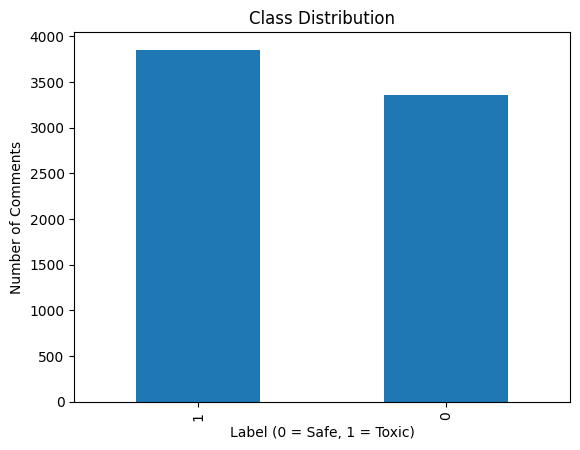

In [10]:
train_df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Label (0 = Safe, 1 = Toxic)")
plt.ylabel("Number of Comments")
plt.show()


In [11]:
import re
import emoji

def clean_text(text):
    text = text.lower()                      # lowercase
    text = re.sub(r"http\S+", "", text)      # remove links
    text = re.sub(r"@\w+", "", text)         # remove usernames
    text = emoji.replace_emoji(text, replace="")  # remove emojis
    text = re.sub(r"[^a-z\s]", "", text)     # remove symbols/numbers
    text = re.sub(r"\s+", " ", text).strip()
    return text


In [12]:
train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)


In [13]:
train_df[["text", "clean_text"]].head(5)


,text,clean_text
0,pichwara se akhrot kahe fod rahe ho chicha,pichwara se akhrot kahe fod rahe ho chicha
1,bhaunk bhaunk ke pagal ho jaata ab tak....,bhaunk bhaunk ke pagal ho jaata ab tak
2,shivsaina nam mulla saina rakh hijra uddh...,shivsaina nam mulla saina rakh hijra uddhav th...
3,there are some yahodi daboo like imran chore z...,there are some yahodi daboo like imran chore z...
4,"chutiye ye hunduism ni he islam he , isme koi ...",chutiye ye hunduism ni he islam he isme koi ki...


In [14]:
from transformers import XLMRobertaTokenizer, XLMRobertaForSequenceClassification


In [16]:
tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")


In [17]:
model = XLMRobertaForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=2
)


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)



XLMRobertaForSequenceClassification(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=

In [19]:
device


device(type='cuda')

In [20]:
def tokenize_text(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )


In [21]:
train_encodings = tokenize_text(train_df["clean_text"].tolist())
test_encodings = tokenize_text(test_df["clean_text"].tolist())


In [22]:
train_encodings.keys()


KeysView({'input_ids': tensor([[    0,  2147, 50059,  ...,     1,     1,     1],
        [    0, 12377,  3678,  ...,     1,     1,     1],
        [    0,  6544,   334,  ...,     1,     1,     1],
        ...,
        [    0, 13057, 11083,  ...,     1,     1,     1],
        [    0, 92469, 77610,  ...,     1,     1,     1],
        [    0,  2589, 48543,  ...,     1,     1,     1]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])})

In [23]:
class HateSpeechDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


In [24]:
train_dataset = HateSpeechDataset(train_encodings, train_df["label"].tolist())
test_dataset = HateSpeechDataset(test_encodings, test_df["label"].tolist())


In [ ]:
len(train_dataset), len(test_dataset)


(7209, 2003)

In [25]:
from transformers import Trainer, TrainingArguments


In [26]:
training_args = TrainingArguments(
    output_dir="./results",              # where logs & checkpoints go
    eval_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    learning_rate=2e-5,
    logging_steps=100,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss"
)


In [27]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)


In [28]:
trainer.train()


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: ERROR Invalid API key: API key must have 40+ characters, has 1.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


Epoch,Training Loss,Validation Loss
1,0.467100,0.440217
2,0.292900,0.350999


TrainOutput(global_step=1804, training_loss=0.45061840272266956, metrics={'train_runtime': 531.6393, 'train_samples_per_second': 27.12, 'train_steps_per_second': 3.393, 'total_flos': 763152588294120.0, 'train_loss': 0.45061840272266956, 'epoch': 2.0})

In [29]:
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions
preds = trainer.predict(test_dataset)

# Convert to class labels
y_pred = preds.predictions.argmax(axis=1)
y_true = test_df["label"]


In [30]:
print(classification_report(y_true, y_pred, target_names=["Safe", "Toxic"]))


              precision    recall  f1-score   support

        Safe       0.89      0.87      0.88       933
       Toxic       0.89      0.91      0.90      1070

    accuracy                           0.89      2003
   macro avg       0.89      0.89      0.89      2003
weighted avg       0.89      0.89      0.89      2003



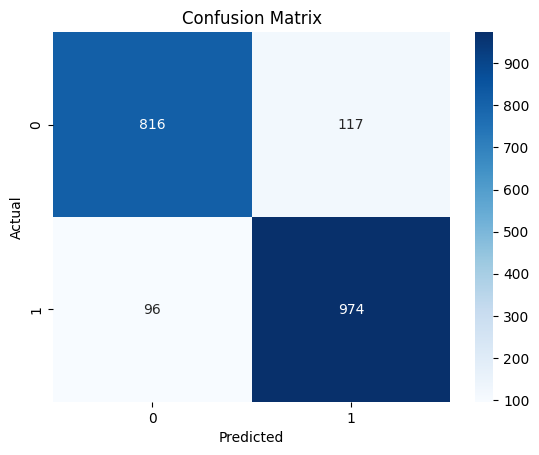

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [32]:
test_df["prediction"] = y_pred
test_df.head(10)


,text,label,clean_text,prediction
0,keh do ke ye sach hai😂😂😂🤫,1,keh do ke ye sach hai,1
1,and i am on ch_air 😆😁 koi acha sa song apki p...,1,and i am on chair koi acha sa song apki pasand...,1
2,tum log pappu mat bano kyunki sonia aur pawar ...,0,tum log pappu mat bano kyunki sonia aur pawar ...,0
3,"neither. bhadwaa tantra, rather. madarjaat ...",0,neither bhadwaa tantra rather madarjaat loug s...,0
4,"bhok ku rha ha.., kutte k pille chal phut yaha...",0,bhok ku rha ha kutte k pille chal phut yaha se...,0
5,kyon k yh kuch logo ki fitrat hai,1,kyon k yh kuch logo ki fitrat hai,1
6,tere kehne ka mtlb....me kamina hu.....😂😂😂😂....,1,tere kehne ka mtlbme kamina hu,1
7,dekh kitna khush ho rha h bc,0,dekh kitna khush ho rha h bc,0
8,leli randi ki leli 🤩🤣,0,leli randi ki leli,0
9,bhai aisi democracy ka kyaa lena...haa udhar w...,1,bhai aisi democracy ka kyaa lenahaa udhar wome...,0


In [33]:
failures =  test_df[test_df["label"] != test_df["prediction"]]
test_df[test_df["label"] != test_df["prediction"]]



,text,label,clean_text,prediction
9,bhai aisi democracy ka kyaa lena...haa udhar w...,1,bhai aisi democracy ka kyaa lenahaa udhar wome...,0
20,randi also meant widow to begin with. the mean...,1,randi also meant widow to begin with the meani...,0
42,aaaaa champli jyada bol mat,0,aaaaa champli jyada bol mat,1
55,#mediastayunbiased mulk me media ik munfird ba...,1,mediastayunbiased mulk me media ik munfird ba ...,0
88,sunni killing a shia....what's new? thank god...,0,sunni killing a shiawhats new thank god he was...,1
...,...,...,...,...
1971,un k bary me bkwas kr rahy ho jinho ny apni sa...,0,un k bary me bkwas kr rahy ho jinho ny apni sa...,1
1972,roshni chand🌙️se hoti hai sitaron se nahi meri...,1,roshni chandse hoti hai sitaron se nahi meri k...,0
1987,india mujy lagta wela e ha.. pakistan k elava ...,1,india mujy lagta wela e ha pakistan k elava kc...,0
1994,tum jaisy logon naye khrab kiya hai kyun ky ...,0,tum jaisy logon naye khrab kiya hai kyun ky ap...,1


In [34]:
model.save_pretrained("saved_model")
tokenizer.save_pretrained("saved_model")


('saved_model/tokenizer_config.json',
 'saved_model/special_tokens_map.json',
 'saved_model/sentencepiece.bpe.model',
 'saved_model/added_tokens.json')

In [35]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)



Accuracy: 0.8936595107338992


In [36]:
print("Accuracy (%):", accuracy * 100)


Accuracy (%): 89.36595107338991


In [37]:
failures[["text", "label", "prediction"]].head(5)


,text,label,prediction
9,bhai aisi democracy ka kyaa lena...haa udhar w...,1,0
20,randi also meant widow to begin with. the mean...,1,0
42,aaaaa champli jyada bol mat,0,1
55,#mediastayunbiased mulk me media ik munfird ba...,1,0
88,sunni killing a shia....what's new? thank god...,0,1


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['label'].plot(kind='hist', bins=20, title='label')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['prediction'].plot(kind='hist', bins=20, title='prediction')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_3.groupby('text').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_12['text'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_12, x='index', y='text', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_13['text'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_13, x='label', y='text', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_14['text'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_14, x='prediction', y='text', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

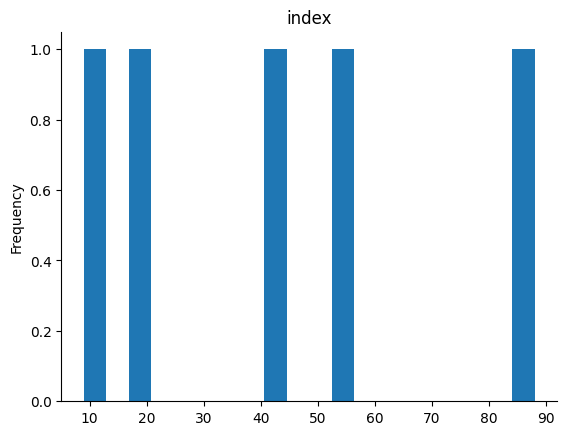

In [38]:
from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
!zip -r saved_model.zip saved_model


updating: saved_model/ (stored 0%)
updating: saved_model/special_tokens_map.json (deflated 52%)
updating: saved_model/tokenizer_config.json (deflated 76%)
updating: saved_model/config.json (deflated 50%)
updating: saved_model/model.safetensors (deflated 31%)
updating: saved_model/sentencepiece.bpe.model (deflated 49%)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')